In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix

import scarf
from scarf.agent import AnalysisConfig, RuntimeConfig, Study, analyze_rna_async
from scarf.writers import SparseToZarr

scarf.configure_output(level="WARNING", progress=False)
teaching_directory = TemporaryDirectory(prefix="scarf-agent-teaching-")
source = Path(teaching_directory.name) / "counts.zarr"
rng = np.random.default_rng(39)
counts = rng.poisson(1, size=(120, 2102)).astype(np.uint32)
for group in range(3):
    counts[group * 40:(group + 1) * 40, 2 + group * 40:42 + group * 40] += (
        rng.poisson(4, size=(40, 40)).astype(np.uint32)
    )
names = ["MT-CO1", "RPL3", *[f"GENE{i}" for i in range(2100)]]
writer = SparseToZarr(
    csr_matrix(counts), str(source), [f"cell{i}" for i in range(120)], names,
    mem_budget="512M", nthreads=1,
)
writer.dump()
prepared = scarf.DataStore(
    str(source), default_assay="RNA", min_features_per_cell=-1,
    nthreads=1, mem_budget="512M",
)
prepared.cells.insert("sample", np.tile(["sample_A", "sample_B"], 60))
prepared.cells.insert("author_annotation", np.repeat(["planted_A", "planted_B", "planted_C"], 40))
initial_selection = prepared.cells.fetch_all("I").copy()
initial_columns = list(prepared.cells.columns)
del prepared, counts

In [2]:
import json

from pydantic_ai.messages import ModelResponse, ToolCallPart
from pydantic_ai.models.function import FunctionModel

observed_decisions = []

async def teaching_decision(messages, info):
    payload = json.loads(messages[-1].parts[-1].content)
    evidence = payload["evidence"]
    schema = info.output_tools[0].parameters_json_schema["title"]
    observed_decisions.append({"stage": payload["stage"], "schema": schema})
    if schema == "ContextDecision":
        answer = {"rationale": "Retain the supplied cohort and declared sample role."}
    elif schema == "AnnotationDecision":
        answer = {
            "annotations": [
                {
                    "clusterId": row["clusterId"],
                    "identity": "unassigned",
                    "rationale": "Synthetic markers do not establish a biological cell identity.",
                }
                for row in evidence["clusters"]
            ]
        }
    elif evidence.get("decisionKind") == "pcProbe":
        chosen = next(
            key for key, value in evidence["experiments"].items()
            if value["pcaDims"] == 30
        )
        answer = {
            "action": "experiment", "optionIds": [chosen], "evidenceIds": ["c0"],
            "rationale": "Measure the registered higher-rank probe for this demonstration.",
        }
    elif "eligibleOptions" in evidence:
        chosen = evidence["eligibleOptions"][0]
        answer = {
            "action": "choose", "optionIds": [chosen], "evidenceIds": [chosen],
            "rationale": "Use the first measured eligible finalist for this demonstration.",
        }
    else:
        assert evidence["decisionKind"] == "nativeShortlist"
        chosen = [row["optionId"] for row in evidence["candidates"][0]["partitions"][:2]]
        answer = {
            "action": "shortlist", "optionIds": chosen, "evidenceIds": chosen,
            "rationale": "Compare two measured baseline resolutions after the independent probes.",
        }
    return ModelResponse(parts=[ToolCallPart("decision", answer)])

teaching_model = FunctionModel(teaching_decision)

In [3]:
result = await analyze_rna_async(
    source,
    run_dir=Path(teaching_directory.name) / "analysis",
    model=teaching_model,
    study=Study(
        context="Synthetic RNA with three planted expression patterns and two interleaved sample labels.",
        objective="Demonstrate bounded population discovery without biological identity claims.",
        sampleColumn="sample",
        excludedColumns=["author_annotation"],
    ),
    config=AnalysisConfig(assay="RNA", maxCandidates=4),
    runtime=RuntimeConfig(nthreads=1, memBudget="512M"),
)
assert result.status == "completed", result.status
pd.DataFrame(result.exploration_coverage["slots"])[["candidateId", "axis", "status", "reason"]]

,candidateId,axis,status,reason
0,c0,baseline,measured,None
1,c1,hvgCount,measured,None
2,c2,pcaDims,measured,None
3,c3,neighborsK,measured,None


In [4]:
pd.DataFrame([
    {
        "candidate": row["candidateId"],
        "HVGs requested": row["parameters"]["hvgCount"],
        "HVGs selected": row["actualHvgCount"],
        "PCs": row["parameters"]["pcaDims"],
        "neighbors": row["parameters"]["neighborsK"],
    }
    for row in result.candidates
])

,candidate,HVGs requested,HVGs selected,PCs,neighbors
0,c0,1000,1000,21,11
1,c1,2000,2000,21,11
2,c2,1000,1000,30,11
3,c3,1000,1000,21,21


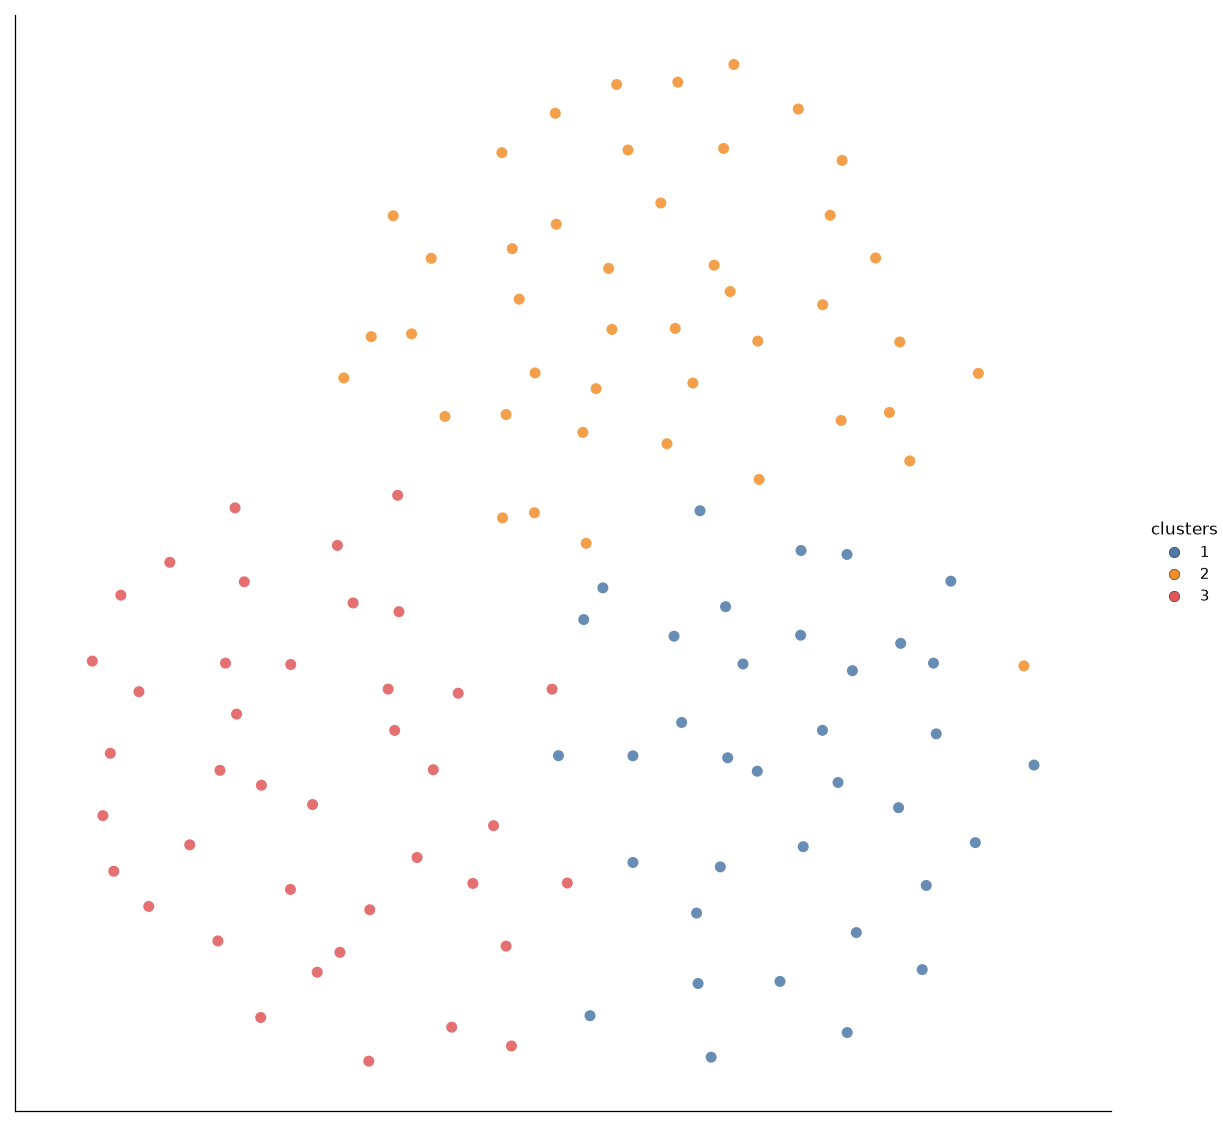

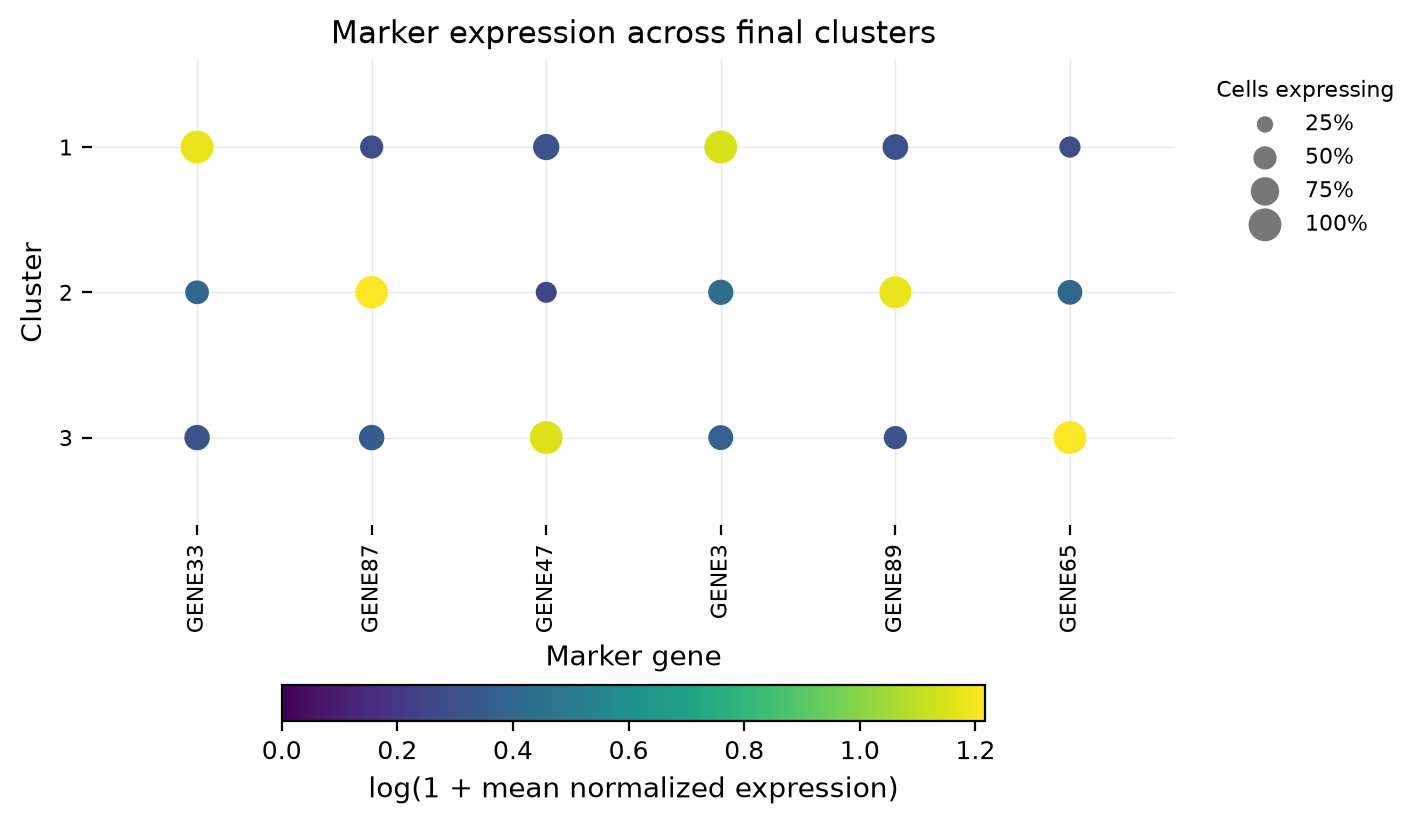

In [5]:
from IPython.display import display

embedding = result.plot_embedding(show=False)
display(embedding.figure)
embedding.close()
marker_plot = result.plot_markers(show=False)
display(marker_plot.figure)
marker_plot.close()

In [6]:
pd.DataFrame(result.annotations)[["clusterId", "identity", "confidence", "rationale"]]

,clusterId,identity,confidence,rationale
0,1,unassigned,low,Synthetic markers do not establish a biologica...
1,2,unassigned,low,Synthetic markers do not establish a biologica...
2,3,unassigned,low,Synthetic markers do not establish a biologica...


In [7]:
compact = result.compact_result
assert compact["finalPipelineRunId"] == result.pipeline.run_id
compact["selectedParameters"]

{'pipelineConfig': {'cellKey': 'I',
  'filtering': {'enabled': False},
  'harmonyBatchColumns': [],
  'hvgCount': 1000,
  'pcaDims': 21,
  'neighborsK': 11,
  'umap': True,
  'tsne': False,
  'leiden': {'partitions': [0.5], 'selected': 0.5},
  'cellCycle': False,
  'paris': False,
  'doublets': False,
  'markers': True,
  'snapshotColumns': ['sample',
   'RNA_nCounts',
   'RNA_nFeatures',
   'RNA_percentMito',
   'RNA_percentRibo'],
  'membershipStrength': False,
  'species': None,
  'params': {'hvg': {'blacklist': '(?i:^mt-)'},
   'ann_index': {'rand_state': 4444, 'ann_parallel': False},
   'embedding_initialization': {'rand_state': 4444},
   'umap': {'random_seed': 4444},
   'leiden': {'random_seed': 4444}},
  'shutdown': {'signalGuardAvailable': True, 'unavailableReason': None}},
 'candidateId': 'c0',
 'resolution': 0.5,
 'requestedHvgCount': 1000,
 'pcaDims': 21,
 'neighborsK': 11,
 'useHarmony': False,
 'actualHvgCount': 1000}

In [8]:
from scarf.agent import open_analysis

reopened = open_analysis(result.run_dir)
report_path = reopened.report()
replayed = reopened.replay_decisions()
assert all(row["valid"] for row in replayed)
after = scarf.DataStore(str(source), zarr_mode="r", nthreads=1, mem_budget="512M")
assert list(after.cells.columns) == initial_columns
np.testing.assert_array_equal(after.cells.fetch_all("I"), initial_selection)
{
    "status": reopened.status,
    "pipeline invocations": len(reopened.pipeline_runs),
    "model decisions": len(observed_decisions),
    "offline replay checks": len(replayed),
    "report": report_path.name,
}

{'status': 'completed',
 'pipeline invocations': 7,
 'model decisions': 5,
 'offline replay checks': 5,
 'report': 'report.html'}